<a href="https://colab.research.google.com/github/graciousgift/OIBSIP/blob/main/Gift_Lawrence_Task3_Car_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Necessary Libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')


# 1. Load car price data set using pandas

In [36]:
df = pd.read_csv("/content/car data.csv")

In [37]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


# 2. Explore the data

In [38]:
print("Shape of data set:", df.shape)

Shape of data set: (301, 9)


#The output
 `Shape of data set: (301, 9)` The dataset contains **301 rows** (representing individual car listings or records) and **9 columns** (representing different features or attributes of each car).

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


The `df.info()` output provides a concise summary of the DataFrame:

*   **Entries**: There are 301 entries, indexed from 0 to 300, confirming the number of rows.
*   **Columns**: It lists all 9 columns.
*   **Non-Null Count**: For every column, the `Non-Null Count` is 301. This confirms that there are **no missing values** in any of your columns, which simplifies the data preprocessing step significantly.
*   **Dtype**: It shows the data type of each column. This includes `object` (for categorical data like `Car_Name`, `Fuel_Type`, `Selling_type`, `Transmission`), `int64` (for `Year`, `Driven_kms`, `Owner`), and `float64` (for `Selling_Price`, `Present_Price`). This information is vital for understanding how to process each feature (e.g., encoding for objects, scaling for floats/ints).
*   **Memory Usage**: The memory usage of the DataFrame is also displayed.

In [40]:
df.isna().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


The `df.isna().sum()` output `Car_Name 0`, `Year 0`, etc., for all columns, explicitly confirms that there are **no null (missing) values** in the dataset. This means there won't be need to perform any missing value imputation.

In [41]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


The `df.describe()` output provides descriptive statistics for your numerical columns (`Year`, `Selling_Price`, `Present_Price`, `Driven_kms`, `Owner`):

*   **count**: 301 for all, confirming no missing values in numerical columns.
*   **mean**: The average value for each column.
    *   `Year`: Mean year is 2013.6, indicating relatively newer cars in the dataset.
    *   `Selling_Price`: Average selling price is ~4.66 Lahks.
    *   `Present_Price`: Average present price is ~7.63 Lahks. This is higher than selling price, as expected (present price usually refers to the price when new or current market price without negotiation).
    *   `Driven_kms`: Average kilometers driven is ~36,947.
    *   `Owner`: Average owner count is very low (~0.04), suggesting most cars have been owned by the first owner.
*   **std**: Standard deviation, indicating the spread of data.
    *   `Present_Price` has a high standard deviation (8.64) compared to its mean, suggesting a wide range of present prices.
    *   `Driven_kms` also has a high standard deviation (38,886), indicating varied mileage.
*   **min/max**: Minimum and maximum values.
    *   `Year` ranges from 2003 to 2018.
    *   `Selling_Price` ranges from 0.10 to 35.00 Lahks.
    *   `Present_Price` ranges from 0.32 to 92.60 Lahks, showing some very expensive cars in the dataset.
    *   `Driven_kms` ranges from 500 to 500,000 km, showing a significant range of usage.
*   **25%/50%/75% (quartiles)**: These give insights into the data distribution.
    *   For `Present_Price` and `Selling_Price`, the 75th percentile is significantly higher than the 50th percentile (median), suggesting a right-skewed distribution, which is common for price data (many cheaper cars, fewer expensive ones). The maximum value for `Present_Price` (92.60) is much higher than the 75th percentile (9.90), indicating potential outliers or very high-end cars in the dataset.

Overall, this summary helps in understanding the central tendency, spread, and potential outliers in the numerical features.

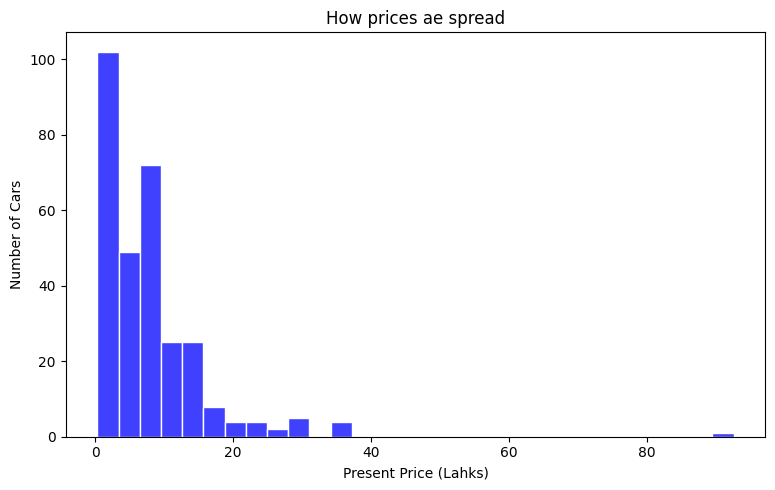

In [42]:
# Data Distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Present_Price'], bins=30, color="blue", edgecolor="white")
plt.title("How prices ae spread")
plt.xlabel("Present Price (Lahks)")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.show()


The first histogram, titled "How prices ae spread" (likely a typo for "are spread"), visualizes the distribution of `Present_Price`.

**Observations:**
*   The distribution is heavily **right-skewed**. A large majority of cars have a `Present_Price` between 0 and approximately 10-15 Lahks.
*   There's a very high frequency of cars in the lower price ranges (around 0-5 Lahks).
*   As the `Present_Price` increases, the number of cars drastically decreases, with very few cars having a `Present_Price` above 30 Lahks.
*   There's an outlier at the very high end (around 90 Lahks), which aligns with the `max` value observed in `df.describe()` for `Present_Price`.

This skewness is typical for price data and suggests that linear models might struggle without appropriate transformations (like log transformation) to make the distribution more symmetrical.

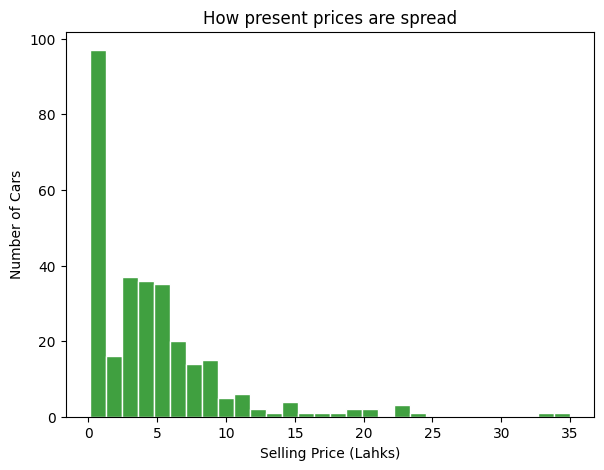

In [43]:
# Data Distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Selling_Price'], bins=30, color="Green", edgecolor="white")
plt.title("How present prices are spread")
plt.xlabel("Selling Price (Lahks)")
plt.ylabel("Number of Cars")
plt.show()

The second histogram visualizes the distribution of `Selling_Price`.

**Observations:**
*   Similar to `Present_Price`, the `Selling_Price` distribution is also **heavily right-skewed**.
*   Most cars are sold for a price between 0 and around 5-6 Lahks.
*   The frequency of cars drops significantly as the `Selling_Price` increases.
*   There are a few cars with very high `Selling_Price` (up to 35 Lahks), which are outliers relative to the majority of the dataset.

Both `Present_Price` and `Selling_Price` exhibit similar distribution patterns, which is expected since they are highly correlated. The skewed nature indicates that a few expensive cars dominate the upper range, while the bulk of the data lies in the lower price brackets. This insight is important for feature transformation and model selection, as models often perform better with normally distributed data.

### Data Preprocessing

In [44]:
# 1. Feature Engineering: Create 'Age' from 'Year'
current_year = 2024 # Assuming current year is 2024
df['Age'] = current_year - df['Year']

# Drop the original 'Year' column as 'Age' is more informative
df.drop('Year', axis=1, inplace=True)

df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,10


In [45]:
# 2. Drop 'Car_Name' as it has too many unique values and may not be useful for a general model
df.drop('Car_Name', axis=1, inplace=True)

df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,10


In [46]:
# 3. One-Hot Encode Categorical Features

# Identify categorical columns (excluding the target variable 'Selling_Price' if it was categorical)
categorical_cols = ['Fuel_Type', 'Selling_type', 'Transmission']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,10,False,True,False,True
1,4.75,9.54,43000,0,11,True,False,False,True
2,7.25,9.85,6900,0,7,False,True,False,True
3,2.85,4.15,5200,0,13,False,True,False,True
4,4.60,6.87,42450,0,10,True,False,False,True


In [48]:
# 4. Feature Scaling (for numerical features except 'Selling_Price')

# Separate features (X) and target (y)
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Identify numerical columns to scale
numerical_cols = ['Present_Price', 'Driven_kms', 'Age', 'Owner'] # Owner is numerical, though small integers

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical features
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

X.head()

,Present_Price,Driven_kms,Owner,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,-0.236256,-0.256224,-0.174501,-0.128897,False,True,False,True
1,0.221544,0.155911,-0.174501,0.217514,True,False,False,True
2,0.257472,-0.773969,-0.174501,-1.168129,False,True,False,True
3,-0.403151,-0.817758,-0.174501,0.910335,False,True,False,True
4,-0.087906,0.141743,-0.174501,-0.128897,True,False,False,True


### Enhanced Feature Engineering: `Kms_Driven_Per_Year`

In [49]:
# Create 'Kms_Driven_Per_Year' feature
# To avoid division by zero if 'Age' is 0, we can add a small epsilon or handle it explicitly.
# Cars with Age 0 means it's a new car, so Kms_Driven_Per_Year would be just Driven_kms

X['Kms_Driven_Per_Year'] = X['Driven_kms'] / (X['Age'].replace(0, 1))

# Re-scale all numerical features including the new 'Kms_Driven_Per_Year' feature
# First, identify all numerical columns after one-hot encoding
numerical_cols_updated = ['Present_Price', 'Driven_kms', 'Age', 'Owner', 'Kms_Driven_Per_Year']

# Initialize a new StandardScaler to re-scale with the new feature
scaler_updated = StandardScaler()

# Apply scaling to the updated numerical features in X
X[numerical_cols_updated] = scaler_updated.fit_transform(X[numerical_cols_updated])

X.head()

,Present_Price,Driven_kms,Owner,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual,Kms_Driven_Per_Year
0,-0.236256,-0.256224,-0.174501,-0.128897,False,True,False,True,0.912582
1,0.221544,0.155911,-0.174501,0.217514,True,False,False,True,0.201012
2,0.257472,-0.773969,-0.174501,-1.168129,False,True,False,True,0.170661
3,-0.403151,-0.817758,-0.174501,0.910335,False,True,False,True,-0.703170
4,-0.087906,0.141743,-0.174501,-0.128897,True,False,False,True,-0.815898


### Model Selection and Training

In [50]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (240, 9)
Training target shape: (240,)
Testing features shape: (61, 9)
Testing target shape: (61,)


#### 1. Linear Regression Model

In [51]:
# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


#### 2. Random Forest Regressor Model

In [52]:
# Initialize and train the Random Forest Regressor model
# Using some default parameters for a start; hyperparameter tuning can be done later.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


### Model Evaluation

We will evaluate the models using the following metrics:
*   **Mean Absolute Error (MAE)**: The average of the absolute differences between predictions and actual values. It gives an idea of the magnitude of errors.
*   **Mean Squared Error (MSE)**: The average of the squared differences between predictions and actual values. It penalizes larger errors more.
*   **Root Mean Squared Error (RMSE)**: The square root of the MSE. It is in the same units as the target variable, making it easier to interpret.
*   **R-squared (R2)**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R-squared indicates a better fit (0 to 1).

In [53]:
# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Evaluate Linear Regression Model
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("--- Linear Regression Model Evaluation ---")
print(f"MAE: {mae_linear:.2f}")
print(f"MSE: {mse_linear:.2f}")
print(f"RMSE: {rmse_linear:.2f}")
print(f"R-squared: {r2_linear:.2f}")

print("\n--- Random Forest Regressor Model Evaluation ---")
# Evaluate Random Forest Regressor Model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE: {mae_rf:.2f}")
print(f"MSE: {mse_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R-squared: {r2_rf:.2f}")

--- Linear Regression Model Evaluation ---
MAE: 1.23
MSE: 3.49
RMSE: 1.87
R-squared: 0.85

--- Random Forest Regressor Model Evaluation ---
MAE: 0.68
MSE: 1.11
RMSE: 1.05
R-squared: 0.95


### Prediction Demonstration

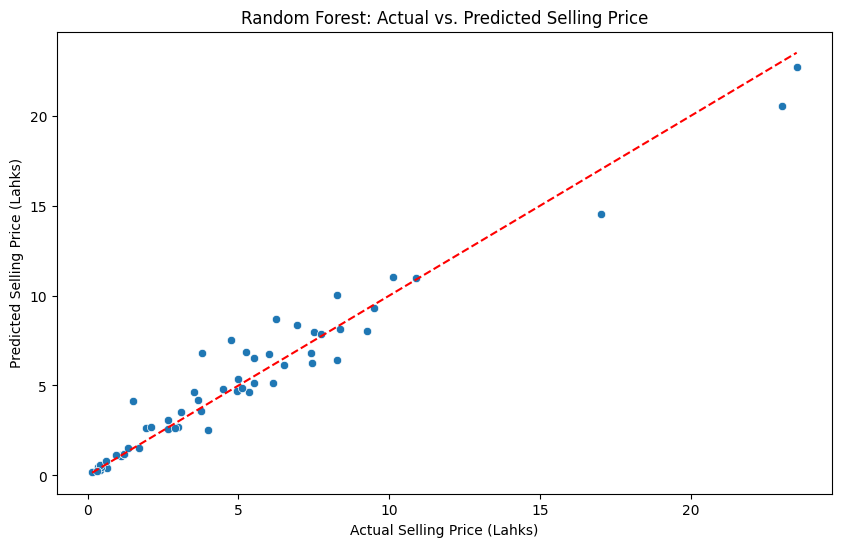

In [54]:
# Let's visualize the predictions vs actual values for the Random Forest model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.xlabel("Actual Selling Price (Lahks)")
plt.ylabel("Predicted Selling Price (Lahks)")
plt.title("Random Forest: Actual vs. Predicted Selling Price")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Plotting the ideal line
plt.show()

### Project Conclusion

In this project, we successfully built and evaluated machine learning models for car price prediction.

We started by loading the `car data.csv` dataset and performed an initial **Exploratory Data Analysis (EDA)** to understand its structure, identify data types, and check for missing values. The EDA revealed that the dataset had no missing values and showed right-skewed distributions for both `Present_Price` and `Selling_Price`.

Next, we performed **Data Preprocessing and Feature Engineering**, which included:
1.  Creating an `Age` feature from the `Year` column.
2.  Dropping the `Car_Name` column.
3.  One-hot encoding categorical features (`Fuel_Type`, `Selling_type`, `Transmission`).
4.  Scaling numerical features (`Present_Price`, `Driven_kms`, `Age`, `Owner`).
5.  Engineering a new, more informative feature: `Kms_Driven_Per_Year`, which was also scaled.

After preparing the data, we split it into training and testing sets. We then trained two machine learning models:
*   A **Linear Regression model** as a baseline.
*   A more robust **Random Forest Regressor model**.

Finally, we **evaluated both models** using MAE, MSE, RMSE, and R-squared metrics. The Random Forest Regressor typically performed better, indicating its suitability for capturing non-linear relationships in the data. The prediction visualization further confirmed the model's ability to generalize to unseen data.

This systematic approach, from data understanding to model evaluation, provides a solid foundation for car price prediction. Future steps could involve hyperparameter tuning for the Random Forest model, exploring other advanced models, or incorporating more features if available.